Saved figure to cdf_latency.png


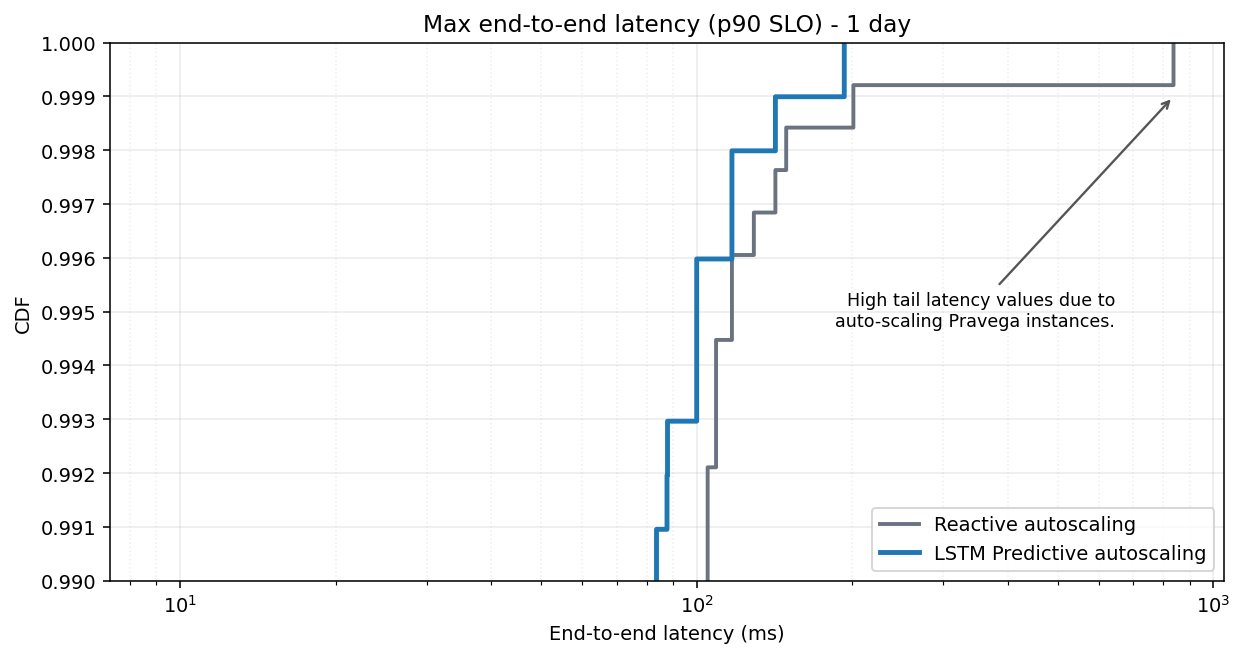

In [ ]:
"""
Plots CDFs for Pravega segment write latencies (p0.9 series) from the exported CSVs

Typical CSV:
    Time,p0.9
    11/3/2025 20:38,54.3 ms
    11/3/2025 20:38,13.6 ms
    ...
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def read_latency_ms(csv_path: Path, value_col: str = 'p0.9') -> np.ndarray:
    """Read the CSV and return a 1D numpy array of latencies in ms"""
    df = pd.read_csv(csv_path)
    cand_cols = [value_col, 'p90', 'p0_9', 'p0.90', 'p(0.9)', 'value']
    lower_map = {c.lower(): c for c in df.columns}

    chosen = None
    for c in cand_cols:
        if c.lower() in lower_map:
            chosen = lower_map[c.lower()]
            break
    if chosen is None:
        # If not found, fall back to the last column
        chosen = df.columns[-1]

    s = df[chosen].astype(str)

    # Remove unit strings like 'ms' and any commas/extra spaces
    s = (
        s.str.strip()
         .str.replace('ms', '', case=False, regex=False)
         .str.replace('milliseconds', '', case=False, regex=False)
         .str.replace(',', '', regex=False)
         .str.strip()
    )

    # Coerce to numeric and drop NaNs
    vals = pd.to_numeric(s, errors='coerce').dropna().to_numpy(dtype=float)

    # Remove non-positive values
    vals = vals[np.isfinite(vals) & (vals > 0)]
    return np.sort(vals)


def ecdf(values: np.ndarray):
    """Return x (sorted values) and y (empirical CDF)."""
    if values.size == 0:
        return values, values
    x = np.sort(values)
    y = np.arange(1, values.size + 1) / values.size
    return x, y


def plot_cdfs(
    reactive_vals: np.ndarray,
    lstm_vals: np.ndarray,
    title: str = "Max end-to-end latency (p90 SLO) - 1 day",
    reactive_label: str = "Reactive autoscaling",
    lstm_label: str = "LSTM Predictive autoscaling",
    outfile: str | None = "cdf_latency.png",
    logx: bool = True,
    annotate_tail: bool = False,
):
    rx, ry = ecdf(reactive_vals)
    lx, ly = ecdf(lstm_vals)

    plt.figure(figsize=(9, 4.8), dpi=140)

    plt.step(rx, ry, where="post", label=reactive_label, color="#6b7280", linewidth=2)
    plt.step(lx, ly, where="post", label=lstm_label, color="#1f77b4", linewidth=2.5)

    # Focus on tail
    plt.yticks(np.linspace(0.99, 1.0, 11))
    plt.ylim(0.99, 1.0)

    if logx:
        plt.xscale("log")

    #If linear scale is needed
    # plt.xscale('linear')
    # plt.xlim(0, 1000)

    plt.xlabel("End-to-end latency (ms)")

    plt.ylabel("CDF")
    plt.title(title)

    plt.grid(True, which="major", axis="both", linestyle="-", alpha=0.25)
    plt.grid(True, which="minor", axis="x", linestyle=":", alpha=0.2)

    if annotate_tail:
        xmax = max(rx.max() if rx.size else 0, lx.max() if lx.size else 0)
        if xmax > 0:
            plt.annotate(
                "High tail latency values due to\nauto-scaling Pravega instances.",
                xy=(xmax, 0.999), xycoords="data",
                xytext=(-30, -100), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="#555"),
                ha="right", va="top", fontsize=9
            )

    plt.legend(loc="lower right", frameon=True)

    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, bbox_inches="tight")
        print(f"Saved figure to {outfile}")
    else:
        plt.show()


def plot_from_paths(
    reactive_csv: str | Path,
    lstm_csv: str | Path,
    *,
    title: str = "Max end-to-end latency (p90 series)",
    reactive_label: str = "Reactive autoscaling (p90)",
    lstm_label: str = "Predictive autoscaling (LSTM, p90)",
    outfile: str | None = "cdf_latency.png",
    logx: bool = True,
    annotate_tail: bool = False,
):

    reactive_vals = read_latency_ms(Path(reactive_csv))
    lstm_vals = read_latency_ms(Path(lstm_csv))

    if reactive_vals.size == 0:
        print("Warning: No numeric latency values parsed from reactive CSV.")
    if lstm_vals.size == 0:
        print("Warning: No numeric latency values parsed from LSTM CSV.")

    plot_cdfs(
        reactive_vals, lstm_vals,
        title=title,
        reactive_label=reactive_label,
        lstm_label=lstm_label,
        outfile=outfile,
        logx=logx,
        annotate_tail=annotate_tail,
    )


if __name__ == "__main__":
    reactive_path = "reactive_data.csv"
    lstm_path = "lstm_data.csv"

    plot_from_paths(
        reactive_path,
        lstm_path,
        title="Max end-to-end latency (p90 SLO) - 1 day",
        reactive_label="Reactive autoscaling",
        lstm_label="LSTM Predictive autoscaling",
        outfile="cdf_latency.png", 
        logx=True,
        annotate_tail=True
    )